In [1]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
import sys, os
sys.path.append(os.path.abspath('../'))
from src.operations import parity_operator, rotation_operator
from src.spin import Spin

In [24]:
nucleus = Spin(I=7/2)
d_angle = np.pi/100
angles = np.arange(0, 2*np.pi + d_angle, d_angle)
states = np.zeros((len(angles), nucleus.dim), dtype=complex)
for i, angle in enumerate(angles):
    global_rotation = rotation_operator(nucleus.I, d_angle, axis='x')
    nucleus.apply_operator(global_rotation)
    states[i] = nucleus.state.full().flatten()

Text(0, 0.5, 'Population')

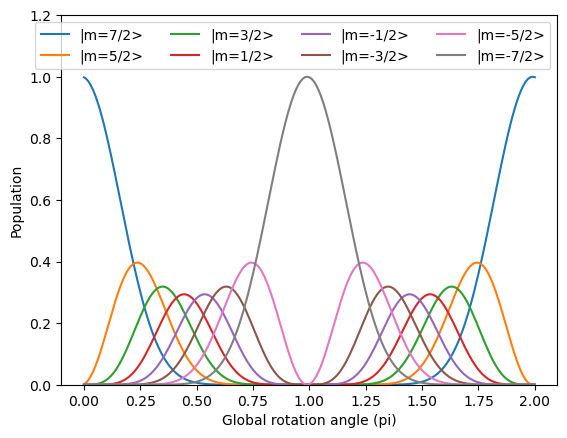

In [44]:
plt.plot(angles/np.pi, np.abs(states)**2)
plt.legend([f'|m={m}/2>' for m in range(int(nucleus.I*2), int(-nucleus.I*2 - 1), -2)], ncols=4, loc='upper right')
plt.ylim([0, 1.2])
plt.xlabel('Global rotation angle (pi)')
plt.ylabel('Population')